# Style Transfer with GPT Image 1

Upload one image for the **subject** (what you want depicted) and another
for the **style** (how you want it to look). GPT-5.2 describes each, then
GPT Image 1 generates a new image combining them.

**How to use:**
1. Run the *Setup* cell once (imports + API key).
2. Run the *Helpers* cell once to define the pipeline functions.
3. Run the **Generate** cell whenever you want to make a new image.
   It will prompt you to upload two files: first the content image, then the style image.

In [ ]:
# === Setup: imports and OpenAI client ===
# Run this cell once per session.

import os
import base64
from openai import OpenAI
from PIL import Image as PILImage
from IPython.display import Image, display
from google.colab import files

# Paste your OpenAI API key here (or load it from an env var / Colab secret).
OPENAI_API_KEY = ""

client = OpenAI(api_key=OPENAI_API_KEY)


In [ ]:
# === Helpers: image prep + captioning + style transfer ===
# Run this cell once per session. You don't need to touch anything here
# unless you want to tweak prompts, models, or image sizes.

import base64
from io import BytesIO

def prepare_image(image_path, output_path):
    """Convert an uploaded image to a PNG (<4 MB, RGB) and return a data URL.

    The vision model needs a URL to see the image. Since the user's file is local,
    we encode it as a base64 data URL so we don't have to host it anywhere.
    """
    img = PILImage.open(image_path)

    # Drop alpha / palette modes — APIs expect RGB PNGs.
    if img.mode in ("RGBA", "P"):
        img = img.convert("RGB")
    img.save(output_path, "PNG", optimize=True)

    # Shrink iteratively until under 4 MB (a safe limit for the vision API).
    while os.path.getsize(output_path) / (1024 * 1024) >= 4:
        img = img.resize(
            (int(img.width * 0.9), int(img.height * 0.9)),
            PILImage.Resampling.LANCZOS,
        )
        img.save(output_path, "PNG", optimize=True)

    # Encode as a data URL so it can be passed directly into the chat API.
    with open(output_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return f"data:image/png;base64,{b64}"


def get_image_caption(client, image_url):
    """Ask the vision model to describe the *subject matter* of an image."""
    response = client.chat.completions.create(
        model="gpt-5.2",
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text":
                    "Describe this image in detail, focusing on the key elements, "
                    "composition, and subject matter. Be specific but concise."},
                {"type": "image_url", "image_url": {"url": image_url}},
            ],
        }],
    )
    return response.choices[0].message.content


def get_style_description(client, image_url):
    """Ask the vision model to describe the *artistic style* of an image (not the subject)."""
    response = client.chat.completions.create(
        model="gpt-5.2",
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text":
                    "Describe the artistic style of this image, including colors, "
                    "techniques, mood, and visual characteristics. Focus on HOW "
                    "it's made rather than WHAT it shows."},
                {"type": "image_url", "image_url": {"url": image_url}},
            ],
        }],
    )
    return response.choices[0].message.content


def create_styled_image(client, content_description, style_description,
                        output_path="styled_image.png"):
    """Use gpt-image-2 to render `content_description` in the given `style_description`.

    Unlike DALL·E 3 (which returned a hosted URL), gpt-image-1 returns the image
    as base64. We decode it, save to disk, and return the local path so the
    caller can display it.
    """
    prompt = (
        f"Create an image showing {content_description}. "
        f"Apply the following artistic style: {style_description}. "
        "Maintain the original subject matter while fully adopting the reference style."
    )
    response = client.images.generate(
        model="gpt-image-1-mini",
        prompt=prompt,
        n=1,
        size="1024x1024",   # any valid gpt-image-2 size works; "auto" lets the model decide
        quality="high",     # "low" | "medium" | "high" | "auto" — replaces DALL·E 3's "standard"
    )

    # gpt-image-2 returns base64, not a URL — decode it.
    image_b64 = response.data[0].b64_json
    image_bytes = base64.b64decode(image_b64)
    with open(output_path, "wb") as f:
        f.write(image_bytes)
    return output_path


def _upload_one(label):
    """Prompt for a single upload and return its filename."""
    print(f"Please upload your {label} image...")
    uploaded = files.upload()
    return next(iter(uploaded))


def generate_styled_image():
    """End-to-end pipeline: upload content + style → caption each → final image."""
    # 1. Get both images from the user. Two separate prompts so it's clear which is which.
    content_file = _upload_one("CONTENT (the subject you want depicted)")
    style_file   = _upload_one("STYLE (the look you want applied)")

    # 2. Normalize each image and get a data URL we can pass to the vision model.
    content_url = prepare_image(content_file, "content_image.png")
    style_url   = prepare_image(style_file,   "style_image.png")

    # 3. Describe each image — subject for content, aesthetic for style.
    content_desc = get_image_caption(client, content_url)
    style_desc   = get_style_description(client, style_url)
    print(f"Content Desc: {content_desc}\n")
    print(f"Style Desc: {style_desc}\n")

    # 4. Ask gpt-image-2 to render the content in the style.
    final_path = create_styled_image(client, content_desc, style_desc)

    # 5. Show the final image inline. Note: Image now takes a local file, not a URL.
    print("Final styled image (gpt-image-2):")
    display(Image(filename=final_path))

    return final_path

## Generate a new image

Run the cell below to create a new styled image. You'll be asked to upload
**two files in order**: first the content image, then the style image.

Please upload your CONTENT (the subject you want depicted) image...


Saving white-cat-breeds-kitten-in-grass-67bf648a54a3b.avif to white-cat-breeds-kitten-in-grass-67bf648a54a3b (1).avif
Please upload your STYLE (the look you want applied) image...


Saving leonardo-da-vinci-style-vintage-600nw-2590132275.webp to leonardo-da-vinci-style-vintage-600nw-2590132275 (1).webp
Content Desc: A fluffy white kitten with bright blue eyes is centered in the frame, walking toward the camera across short green grass. Its tail is raised high and curled slightly, giving a sense of motion and alertness. The photo is taken at a low, ground-level angle with shallow depth of field, leaving the background as a soft green blur with faint hints of distant foliage and a few subtle colored spots. The kitten’s fur is sharply detailed against the smooth, defocused backdrop, making it the clear focal point.

Style Desc: The image is rendered in a **vintage technical-illustration / steampunk “blueprint”** style, made to resemble an old engineering page rather than a modern drawing.

- **Color palette:** Dominated by **warm sepia and parchment tans**, with darker **brown/near-black ink** for linework. Subtle value variation comes from paper aging rather than sh

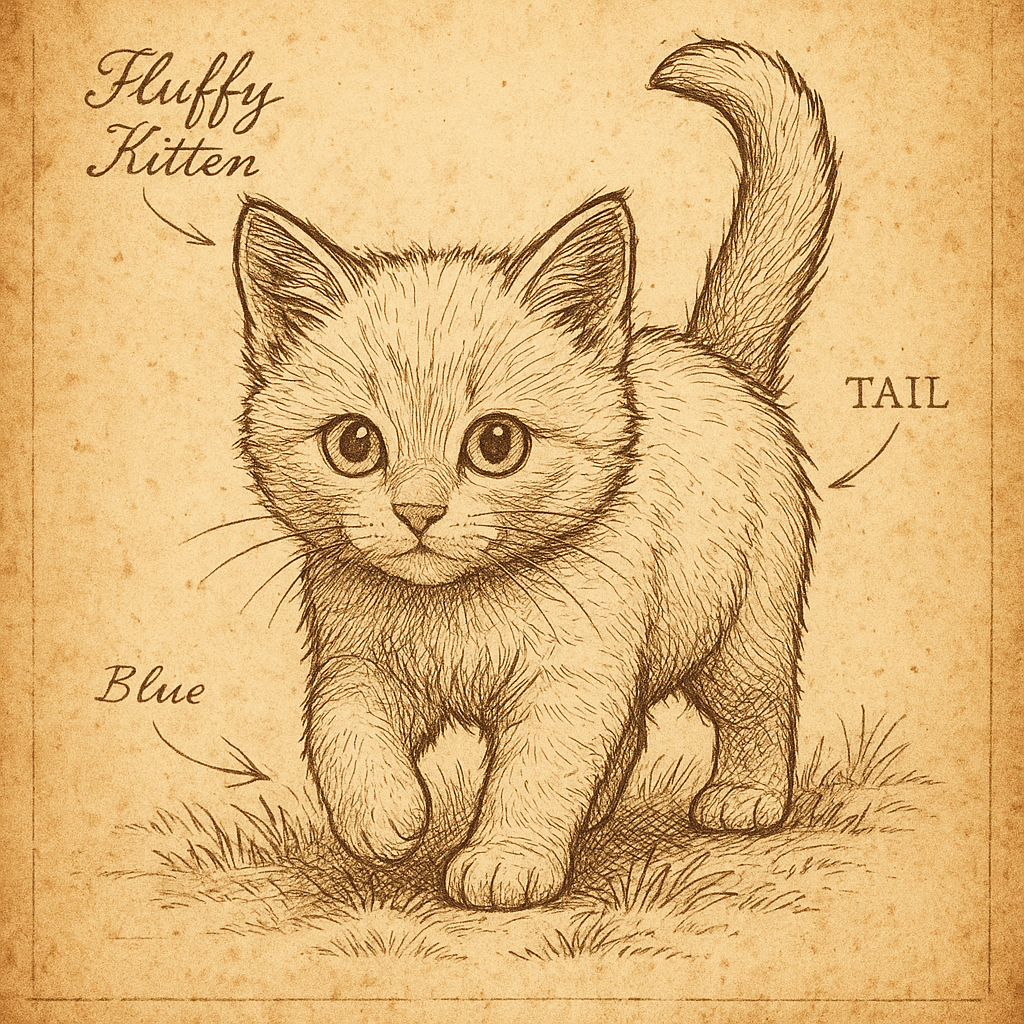

In [ ]:
# === Generate ===
# This is the only cell you need to re-run to make a new image.
final_image_path = generate_styled_image()